## Create a MeshFL-Compatible Dataset Database

This cell creates a SQLite database from two folders:

- one containing raw MRI NIfTI files
- one containing corresponding label NIfTI files

The output database follows the schema expected by MeshFL and can be used directly for training.

**Clone MeshFL Repo**

In [1]:
!git clone https://github.com/Mmasoud1/MeshFL.git
%cd MeshFL

Cloning into 'MeshFL'...
remote: Enumerating objects: 843, done.
remote: Counting objects: 100% (140/140), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 843 (delta 67), reused 99 (delta 36), pack-reused 703 (from 1)
Receiving objects: 100% (843/843), 6.96 MiB | 6.28 MiB/s, done.
Resolving deltas: 100% (423/423), done.
Filtering content: 100% (3/3), 440.32 MiB | 10.34 MiB/s, done.
/content/MeshFL


In [2]:
from pathlib import Path
import sqlite3
import zlib
import numpy as np
import nibabel as nib
import os

# Set paths of inputs (raws and labels ) and output db
raw_dir = Path("/content/MeshFL/Examples/dataset_create/data/raw_nii")         # folder containing raw MRI .nii/.nii.gz
label_dir = Path("/content/MeshFL/Examples/dataset_create/data/label_nii")     # folder containing label .nii/.nii.gz
output_db = Path("/content/MeshFL/Examples/dataset_create/mindboggle_custom.db")

# Expected MRI shape for MeshFL
expected_shape = (256, 256, 256)

# True means use labels for both Label and GWlabels columns in the db
duplicate_label_into_both = True

# helper functions
def strip_nii_suffix(name: str) -> str:
    """To remove .nii or .nii.gz suffix."""
    if name.endswith(".nii.gz"):
        return name[:-7]
    elif name.endswith(".nii"):
        return name[:-4]
    return name

def list_nii_files(folder: Path):
    return sorted(list(folder.glob("*.nii")) + list(folder.glob("*.nii.gz")))

def load_nifti_float32(path: Path) -> np.ndarray:
    arr = nib.load(str(path)).get_fdata().astype(np.float32)
    return arr

def compress_array(arr: np.ndarray) -> bytes:
    return zlib.compress(arr.astype(np.float32).tobytes())

# Read all subjects and GT from paths
raw_files = list_nii_files(raw_dir)
label_files = list_nii_files(label_dir)

if not raw_files:
    raise FileNotFoundError(f"No raw NIfTI files found in {raw_dir}")
if not label_files:
    raise FileNotFoundError(f"No label NIfTI files found in {label_dir}")

raw_map = {strip_nii_suffix(f.name): f for f in raw_files}
label_map = {strip_nii_suffix(f.name): f for f in label_files}

common_keys = sorted(set(raw_map.keys()) & set(label_map.keys()))

print(f"Found {len(raw_files)} raw files")
print(f"Found {len(label_files)} label files")
print(f"Matched {len(common_keys)} pairs")

if not common_keys:
    raise ValueError("No matching raw/label pairs found by filename stem.")

# Show unmatched files
# Both files (ie. Raw and GT) should have the same name
# For example:
#  data/raw_nii/subject1.nii.gz and data/label_nii/subject1.nii.gz
raw_only = sorted(set(raw_map.keys()) - set(label_map.keys()))
label_only = sorted(set(label_map.keys()) - set(raw_map.keys()))

if raw_only:
    print("\nRaw files without matching label:")
    for k in raw_only[:10]:
        print("-", k)

if label_only:
    print("\nLabel files without matching raw:")
    for k in label_only[:10]:
        print("-", k)

# Create dataset
if output_db.exists():
    output_db.unlink()

conn = sqlite3.connect(str(output_db))
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE mindboggle101 (
    ID INTEGER PRIMARY KEY,
    Image BLOB,
    Label BLOB,
    GWlabels BLOB,
    ANAlabels BLOB
)
""")

# Inset data
inserted = 0
skipped = []

for idx, key in enumerate(common_keys, start=1):
    raw_path = raw_map[key]
    label_path = label_map[key]

    try:
        raw_arr = load_nifti_float32(raw_path)
        label_arr = load_nifti_float32(label_path)

        if raw_arr.shape != expected_shape:
            skipped.append((key, f"raw shape {raw_arr.shape} != {expected_shape}"))
            continue

        if label_arr.shape != expected_shape:
            skipped.append((key, f"label shape {label_arr.shape} != {expected_shape}"))
            continue

        image_blob = compress_array(raw_arr)

        if duplicate_label_into_both:
            label_blob = compress_array(label_arr)
            gwlabel_blob = compress_array(label_arr)
        else:
            label_blob = compress_array(np.zeros(expected_shape, dtype=np.float32))
            gwlabel_blob = compress_array(label_arr)

        analabel_blob = compress_array(np.zeros(expected_shape, dtype=np.float32))

        cursor.execute(
            """
            INSERT INTO mindboggle101 (ID, Image, Label, GWlabels, ANAlabels)
            VALUES (?, ?, ?, ?, ?)
            """,
            (idx, image_blob, label_blob, gwlabel_blob, analabel_blob)
        )
        inserted += 1

    except Exception as e:
        skipped.append((key, str(e)))

conn.commit()


# Summary
print("\nDatabase created:", output_db)
print("Inserted samples:", inserted)
print("Skipped samples:", len(skipped))

if skipped:
    print("\nExamples of skipped files:")
    for item in skipped[:10]:
        print("-", item)

# Verify row count
row_count = cursor.execute("SELECT COUNT(*) FROM mindboggle101").fetchone()[0]
print("Rows in DB:", row_count)

conn.close()

Found 1 raw files
Found 1 label files
Matched 1 pairs

Database created: /content/MeshFL/Examples/dataset_create/mindboggle_custom.db
Inserted samples: 1
Skipped samples: 0
Rows in DB: 1


### Notes

- Raw and label files are matched by filename stem  
  Example:
  - `subject01.nii.gz` ↔ `subject01.nii.gz`

- Volumes are expected to have shape `(256, 256, 256)` for compatibility with the current demo pipeline

- Label files are stored into the `GWlabels` column, which is the label type used by MeshFL in the demo

- The generated database can be copied to:
  - `test_data/<site>/mindboggle.db`

  For example:
  - `test_data/site-1/mindboggle.db`
  - `test_data/site-2/mindboggle.db`

to simulate decentralized training across sites

### **Inspect created DB**

In [3]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(str(output_db))
df = pd.read_sql_query("SELECT ID FROM mindboggle101 LIMIT 10;", conn)
display(df)
print("Total rows:", pd.read_sql_query("SELECT COUNT(*) as n FROM mindboggle101;", conn))
conn.close()

,ID
0,1


Total rows:    n
0  1


In [4]:
import sqlite3
import pandas as pd
from pathlib import Path

db_path = Path("/content/MeshFL/Examples/dataset_create/mindboggle_custom.db")
conn = sqlite3.connect(str(db_path))
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;")
tables = [row[0] for row in cursor.fetchall()]
print("Tables:", tables)

schema_rows = []

for table in tables:
    cursor.execute(f"PRAGMA table_info({table});")
    cols = cursor.fetchall()
    for col in cols:
        schema_rows.append({
            "table": table,
            "column_name": col[1],
            "type": col[2]
        })

schema_df = pd.DataFrame(schema_rows)
display(schema_df)

Tables: ['mindboggle101']


,table,column_name,type
0,mindboggle101,ID,INTEGER
1,mindboggle101,Image,BLOB
2,mindboggle101,Label,BLOB
3,mindboggle101,GWlabels,BLOB
4,mindboggle101,ANAlabels,BLOB


**Decode one sample**

In [5]:
import zlib
import numpy as np
import matplotlib.pyplot as plt

cursor.execute("SELECT ID, Image, GWlabels FROM mindboggle101 LIMIT 1;")
sample_id, image_blob, label_blob = cursor.fetchone()

image = np.frombuffer(zlib.decompress(image_blob), dtype=np.float32).reshape((256, 256, 256))
label = np.frombuffer(zlib.decompress(label_blob), dtype=np.float32).reshape((256, 256, 256))

print("Sample ID:", sample_id)
print("Compressed image bytes:", len(image_blob))
print("Compressed label bytes:", len(label_blob))

print("Image shape:", image.shape)
print("Label shape:", label.shape)
print("Image dtype:", image.dtype)
print("Label dtype:", label.dtype)

print("Image min/max:", image.min(), image.max())
print("Label unique values:", np.unique(label))

Sample ID: 1
Compressed image bytes: 6644115
Compressed label bytes: 291584
Image shape: (256, 256, 256)
Label shape: (256, 256, 256)
Image dtype: float32
Label dtype: float32
Image min/max: 0.0 255.0
Label unique values: [0. 1. 2.]


**Visualize MRI + GT + overlay**

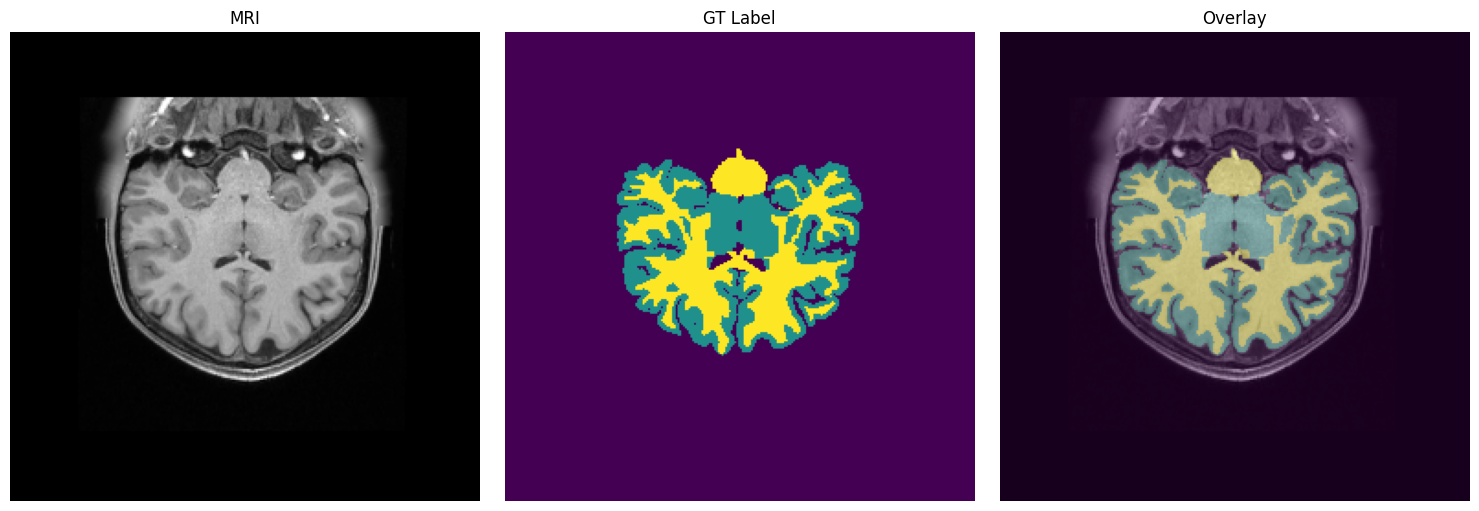

Saved figure: /content/MeshFL/Examples/dataset_create/figures/dataset_sample_overlay.png


In [6]:
from pathlib import Path

out_dir = Path("/content/MeshFL/Examples/dataset_create/figures")  # also fix "Examples" → "examples"
out_dir.mkdir(parents=True, exist_ok=True)

mid_idx = image.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image[:, :, mid_idx].T, cmap="gray", origin="lower")
axes[0].set_title("MRI")
axes[0].axis("off")

axes[1].imshow(label[:, :, mid_idx].T, origin="lower")
axes[1].set_title("GT Label")
axes[1].axis("off")

axes[2].imshow(image[:, :, mid_idx].T, cmap="gray", origin="lower")
axes[2].imshow(label[:, :, mid_idx].T, alpha=0.35, origin="lower")
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.tight_layout()
save_path = out_dir / "dataset_sample_overlay.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", save_path)

## Summary

This notebook demonstrates how to:
- create a MeshFL-compatible SQLite dataset from raw NIfTI MRI and label files
- inspect the resulting database schema
- decode and visualize one stored sample

This workflow can be used to adapt MeshFL to custom datasets while preserving the existing training pipeline.